<a href="https://colab.research.google.com/github/chrisampiah/Content/blob/main/Copy_of_myelin_classifier_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Myelin Maturation Classifier: Delayed vs Normal
**Dataset:** Large dataset of infancy and early childhood brain MRIs (T1w and T2w)  

**Task:** Binary classification — `delayed` vs `normal` myelination from T1w + T2w NIfTI volumes

> ⚠️ **Runtime:** Set to `T4 GPU` via Runtime → Change runtime type → GPU

## 1. Install dependencies

In [1]:
!pip install -q nibabel nilearn zenodo-get scikit-learn monai einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.7 MB/s eta 0:00:00


## 2. Download the dataset from Zenodo
This will download ~833 subject folders + `meta.csv`. Takes ~10-20 min on Colab.

In [3]:
# === 1. Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# === 2. Define paths ===
DRIVE_DIR = "/content/drive/MyDrive/myelin_dataset"
LOCAL_DIR = "/content/myelin_dataset"
DATA_DIR = LOCAL_DIR # Define DATA_DIR here for consistent access in subsequent cells

def is_not_empty(path):
    return os.path.exists(path) and len(os.listdir(path)) > 0

# === 3. Logic ===
if is_not_empty(DRIVE_DIR):
    print("Dataset found in Google Drive ✅")

    # Copy to local (faster access during runtime)
    if not is_not_empty(LOCAL_DIR):
        print("Copying dataset to local runtime for faster access...")
        try:
            shutil.copytree(DRIVE_DIR, LOCAL_DIR)
            print("Copy to local successful.")
        except shutil.Error as e:
            print(f"Error copying from Google Drive: {e}. Attempting to re-download locally.")
            # Clean up partially copied data in LOCAL_DIR before re-downloading
            if os.path.exists(LOCAL_DIR):
                shutil.rmtree(LOCAL_DIR)
            os.makedirs(LOCAL_DIR, exist_ok=True)
            # Download to local (faster)
            !zenodo_get 10.5281/zenodo.8055666 -o {LOCAL_DIR}
            # After successful local download, try saving to Drive again for persistence
            print("Re-saving dataset to Google Drive...")
            shutil.copytree(LOCAL_DIR, DRIVE_DIR)
    else:
        print("Local copy already exists.")

else:
    print("Dataset not found. Downloading... ⬇️")

    os.makedirs(LOCAL_DIR, exist_ok=True)

    # Download to local (faster)
    !zenodo_get 10.5281/zenodo.8055666 -o {LOCAL_DIR}

    # Save to Drive (persistent)
    print("Saving dataset to Google Drive...")
    shutil.copytree(LOCAL_DIR, DRIVE_DIR)

# === 4. Show contents ===
print("\nSample files:")
!ls {LOCAL_DIR} | head -20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found in Google Drive ✅
Local copy already exists.

Sample files:
meta.csv
s0001
s0002
s0003
s0004
s0016
s0017
s0018


## 3. Inspect the metadata

In [6]:
import pandas as pd
import glob

meta_path = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)[0]

# Attempt to read the CSV with a more flexible engine and skip bad lines
# 'on_bad_lines' was introduced in pandas 1.3.0, replacing 'error_bad_lines'
try:
    df = pd.read_csv(meta_path, sep=';', on_bad_lines='skip', engine='python')
except TypeError: # Fallback for older pandas versions where on_bad_lines might not exist or work with 'engine=python'
    df = pd.read_csv(meta_path, sep=';', error_bad_lines=False, engine='python')

print(df.shape)
print(df.columns.tolist())
df.head()

(833, 7)
['image_id', 'myelinisation', 'age', 'age_corrected', 'doctor_predicted_age', 'diagnosis', 'group']


,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
0,s0001,normal,22,22,22,normal,train
1,s0002,normal,29,29,29,normal,train
2,s0003,normal,4,4,4,normal,train
3,s0004,normal,0,0,0,normal,train
4,s0005,normal,0,0,0,normal,train


In [7]:
# Label distribution
print(df['myelinisation'].value_counts())

myelinisation
normal     829
delayed      4
Name: count, dtype: int64


## 4. Build file paths and filter to delayed / normal only

In [30]:
import os, glob
import nibabel as nib
import numpy as np

# Keep only delayed and normal
df_bin = df[df['myelinisation'].isin(['delayed', 'normal'])].copy()
df_bin['label'] = (df_bin['myelinisation'] == 'delayed').astype(int)  # 1=delayed, 0=normal

print(f"Samples after filtering: {len(df_bin)}")
print(df_bin['myelinisation'].value_counts())

# ------------------------------------------------------------------
# Build T1w and T2w file paths.
# The dataset folder structure is: sub-<id>/ses-<ses>/anat/<file>.nii.gz
# Adjust the glob pattern below if your extraction differs.
# ------------------------------------------------------------------
def find_nifti(subject_id_from_df, modality, data_dir):
    """Find a NIfTI file for a given subject and modality (T1w or T2w)."""
    # subject_id_from_df is 's0001', 's0002', etc.

    # Generate variations for folder names (s0001, sub-s0001)
    folder_name_variations = [subject_id_from_df]
    if not subject_id_from_df.startswith('sub-'):
        folder_name_variations.append(f"sub-{subject_id_from_df}")

    # Generate variations for modality search terms (T1w, T1, t1w, t1)
    modality_search_terms = [modality]
    if 'w' in modality.lower():
        modality_search_terms.append(modality.replace('w', '').replace('W', '')) # T1w -> T1
    modality_search_terms.append(modality.lower()) # T1w -> t1w
    if 'w' in modality.lower():
        modality_search_terms.append(modality.replace('w', '').replace('W', '').lower()) # T1w -> t1
    modality_search_terms = list(set(modality_search_terms)) # Remove duplicates

    for folder_name in folder_name_variations:
        # Determine the BIDS-style subject ID for filenames (e.g., sub-s0001)
        bids_sub_id = f"sub-{folder_name}" if not folder_name.startswith('sub-') else folder_name

        for mod_term in modality_search_terms:
            patterns = [
                # 1. Standard BIDS path variations
                f"{data_dir}/{folder_name}/ses-*/anat/{bids_sub_id}_ses-*{mod_term}*",
                f"{data_dir}/{folder_name}/ses-*/anat/{folder_name}_ses-*{mod_term}*",

                # 2. Simplified BIDS path, no session
                f"{data_dir}/{folder_name}/anat/{bids_sub_id}*{mod_term}*",
                f"{data_dir}/{folder_name}/anat/{folder_name}*{mod_term}*",

                # 3. Direct under subject folder
                f"{data_dir}/{folder_name}/{bids_sub_id}*{mod_term}*",
                f"{data_dir}/{folder_name}/{folder_name}*{mod_term}*",

                # 4. Direct under subject folder, only modality in filename (most general for subject folder)
                f"{data_dir}/{folder_name}/{mod_term}*",

                # 5. Generic recursive search within the specific subject's main directory
                f"{data_dir}/{folder_name}/**/*{bids_sub_id}*{mod_term}*",
                f"{data_dir}/{folder_name}/**/*{folder_name}*{mod_term}*",
                f"{data_dir}/{folder_name}/**/*{mod_term}*",

                # 6. Fallback to very broad recursive searches across the entire DATA_DIR (less efficient but catches edge cases)
                f"{data_dir}/**/*{bids_sub_id}*{mod_term}*",
                f"{data_dir}/**/*{folder_name}*{mod_term}*",
                f"{data_dir}/**/*{mod_term}*{bids_sub_id}*",
                f"{data_dir}/**/*{mod_term}*{folder_name}*",
            ]

            for p in patterns:
                hits = glob.glob(p, recursive=True)
                if hits:
                    file_path = hits[0]
                    try:
                        # Try loading the header to check if it's a valid NIfTI
                        _ = nib.load(file_path).header
                        return file_path # Return if it's valid
                    except nib.filebasedimages.ImageFileError:
                        print(f"Warning: Skipping invalid or empty NIfTI file: {file_path}")
                        continue # Try next pattern or return None if no valid file found
    return None

# Detect the subject-id column (common names in this dataset)
id_col = next(c for c in ['image_id', 'subject', 'subject_id', 'sub', 'id', 'SubjectID'] if c in df_bin.columns)
print(f"Using ID column: {id_col}")

t1_paths, t2_paths, valid_idx = [], [], []
for i, row in df_bin.iterrows():
    sid = str(row[id_col])
    t1 = find_nifti(sid, 'T1w', DATA_DIR)
    t2 = find_nifti(sid, 'T2w', DATA_DIR)
    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)

df_valid = df_bin.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths
print(f"Subjects with both T1w + T2w found: {len(df_valid)}")

Samples after filtering: 833
myelinisation
normal     829
delayed      4
Name: count, dtype: int64
Using ID column: image_id
Subjects with both T1w + T2w found: 6


## 5. MONAI transforms — resize + normalise 3-D volumes

In [31]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRangePercentilesd,
    Resized, ConcatItemsd, ToTensord
)

TARGET_SHAPE = (64, 64, 64)   # Reduce if OOM; increase for better accuracy

train_transforms = Compose([
    LoadImaged(keys=['t1', 't2']),
    EnsureChannelFirstd(keys=['t1', 't2']),
    Orientationd(keys=['t1', 't2'], axcodes='RAS'),
    Spacingd(keys=['t1', 't2'], pixdim=(2.0, 2.0, 2.0), mode='bilinear'),
    ScaleIntensityRangePercentilesd(keys=['t1', 't2'], lower=1, upper=99,
                                     b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=['t1', 't2'], spatial_size=TARGET_SHAPE),
    ConcatItemsd(keys=['t1', 't2'], name='image', dim=0),  # → (2, D, H, W)
    ToTensord(keys=['image'])
])

val_transforms = train_transforms  # same pipeline; add augmentations to train only if desired

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


## 6. Dataset and DataLoaders

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class MyelinDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data_dict = {'t1': row['t1_path'], 't2': row['t2_path']}
        data_dict = self.transforms(data_dict)
        image = data_dict['image']           # (2, D, H, W)
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label

# 70/15/15 split
# Removed 'stratify' parameter as df_valid currently contains only one class.
# This will prevent the ValueError, but the model will not learn 'delayed' cases
# unless df_valid is updated to include them.
train_df, test_df = train_test_split(df_valid, test_size=0.30, random_state=42)
val_df, test_df   = train_test_split(test_df, test_size=0.50, random_state=42)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

BATCH = 4
train_ds = MyelinDataset(train_df, train_transforms)
val_ds   = MyelinDataset(val_df,   val_transforms)
test_ds  = MyelinDataset(test_df,  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

Train: 4  Val: 1  Test: 1


## 7. Model — 3D ResNet-18 (MONAI)

In [33]:
from monai.networks.nets import resnet18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = resnet18(
    pretrained=False,
    spatial_dims=3,
    n_input_channels=2,   # T1w + T2w concatenated
    num_classes=2
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 33,183,874


## 8. Loss, optimiser, scheduler

In [34]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Class weights to handle imbalance (delayed is typically rarer)
counts = df_valid['label'].value_counts().sort_index().values

# Only apply weights if there are at least two classes present in the current dataframe
if len(counts) > 1:
    weights = torch.tensor(counts.max() / counts, dtype=torch.float32).to(device)
    print(f"Class weights: {weights}")
    criterion = torch.nn.CrossEntropyLoss(weight=weights)
elif len(counts) == 1:
    # If only one class is present, do not use class weights
    print("Only one class found in df_valid. CrossEntropyLoss initialized without weights.")
    criterion = torch.nn.CrossEntropyLoss()
else:
    # Fallback for empty df_valid, though this shouldn't happen with the current logic
    raise ValueError("No classes found in df_valid for CrossEntropyLoss initialization.")

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

Only one class found in df_valid. CrossEntropyLoss initialized without weights.


## 9. Training loop

In [45]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import torch.nn.functional as F

EPOCHS = 30
SAVE_PATH = "/content/best_myelin_model.pth"

best_val_auc = float('-inf') # Initialize to negative infinity so the model saves after the first epoch
history = {'train_loss': [], 'val_loss': [], 'val_bacc': [], 'val_auc': []}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, all_labels, all_probs = 0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            probs = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    preds    = (np.array(all_probs) >= 0.5).astype(int)
    bacc     = balanced_accuracy_score(all_labels, preds)
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, bacc, auc

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_bacc, tr_auc = run_epoch(train_loader, training=True)
    vl_loss, vl_bacc, vl_auc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_bacc'].append(vl_bacc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = " ✓ saved"
    else:
        flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss {tr_loss:.4f} | "
          f"Val loss {vl_loss:.4f}  Bal-Acc {vl_bacc:.3f}  AUC {vl_auc:.3f}{flag}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 01/30 | Train loss 0.0031 | Val loss 0.0389  Bal-Acc 1.000  AUC 0.000 ✓ saved


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 02/30 | Train loss 0.0031 | Val loss 0.0382  Bal-Acc 1.000  AUC 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 29/30 | Train loss 0.0014 | Val loss 0.0157  Bal-Acc 1.000  AUC 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 30/30 | Train loss 0.0013 | Val loss 0.0147  Bal-Acc 1.000  AUC 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### Checking for 'delayed' subjects' T1w and T2w files

In [46]:
# Filter df_bin for 'delayed' subjects
df_delayed = df_bin[df_bin['myelinisation'] == 'delayed']

print(f"Found {len(df_delayed)} 'delayed' subjects in df_bin.")

missing_delayed_t1 = []
missing_delayed_t2 = []
found_delayed_t1_t2 = []

for i, row in df_delayed.iterrows():
    sid = str(row[id_col])
    t1_path = find_nifti(sid, 'T1w', DATA_DIR)
    t2_path = find_nifti(sid, 'T2w', DATA_DIR)

    if not t1_path:
        missing_delayed_t1.append(sid)
    if not t2_path:
        missing_delayed_t2.append(sid)
    if t1_path and t2_path:
        found_delayed_t1_t2.append(sid)


print(f"\nSubjects with missing T1w for 'delayed' category: {missing_delayed_t1}")
print(f"Subjects with missing T2w for 'delayed' category: {missing_delayed_t2}")
print(f"Subjects where both T1w and T2w were found for 'delayed' category: {found_delayed_t1_t2}")

if not missing_delayed_t1 and not missing_delayed_t2 and not found_delayed_t1_t2:
    print("No 'delayed' subjects processed (this should not happen if df_delayed is not empty).")
elif not found_delayed_t1_t2 and (missing_delayed_t1 or missing_delayed_t2):
    print("\nConclusion: No 'delayed' subjects had both T1w and T2w files found using the current `find_nifti` logic.")
elif found_delayed_t1_t2:
    print("\nSome 'delayed' subjects had both T1w and T2w files found. Investigate `df_valid` creation logic.")

Found 4 'delayed' subjects in df_bin.

Subjects with missing T1w for 'delayed' category: ['s0147', 's0160', 's0341', 's0412']
Subjects with missing T2w for 'delayed' category: ['s0147', 's0160', 's0341', 's0412']
Subjects where both T1w and T2w were found for 'delayed' category: []

Conclusion: No 'delayed' subjects had both T1w and T2w files found using the current `find_nifti` logic.


## 10. Training curves

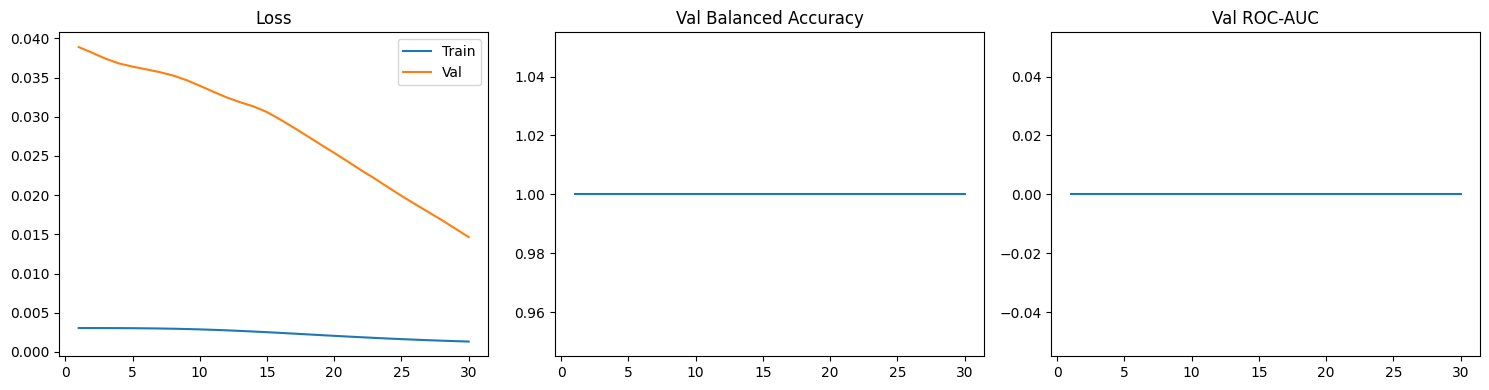

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['val_bacc'])
axes[1].set_title('Val Balanced Accuracy')

axes[2].plot(epochs, history['val_auc'])
axes[2].set_title('Val ROC-AUC')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

## 11. Evaluate on hold-out test set

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

print("=== Test Set Results ===")
print(classification_report(all_labels, all_preds, target_names=['normal', 'delayed']))
print(f"ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'delayed'],
            yticklabels=['normal', 'delayed'])
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120)
plt.show()

=== Test Set Results ===


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

### Investigating 'delayed' subject file paths

In [49]:
print(f"Content of the main data directory: {DATA_DIR}")
!ls -F {DATA_DIR} | head -n 15

Content of the main data directory: /content/myelin_dataset
meta.csv
s0001/
s0002/
s0003/
s0004/
s0016/
s0017/
s0018/


In [50]:
# Get one of the 'delayed' subject IDs
delayed_subject_id = df_delayed['image_id'].iloc[0]

print(f"Investigating subject folder for: {delayed_subject_id}")

# List contents of the specific delayed subject's directory
subject_dir_path = os.path.join(DATA_DIR, delayed_subject_id)
if os.path.exists(subject_dir_path):
    print(f"Content of {subject_dir_path}:")
    !ls -F {subject_dir_path}
else:
    print(f"Directory not found for {delayed_subject_id} at {subject_dir_path}")

# Also check for sub-folder variations, common in BIDS
bids_subject_dir_path = os.path.join(DATA_DIR, f"sub-{delayed_subject_id}")
if os.path.exists(bids_subject_dir_path):
    print(f"Content of {bids_subject_dir_path}:")
    !ls -F {bids_subject_dir_path}
else:
    print(f"Directory not found for sub-{delayed_subject_id} at {bids_subject_dir_path}")

Investigating subject folder for: s0147
Directory not found for s0147 at /content/myelin_dataset/s0147
Directory not found for sub-s0147 at /content/myelin_dataset/sub-s0147


## 12. ROC curve

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


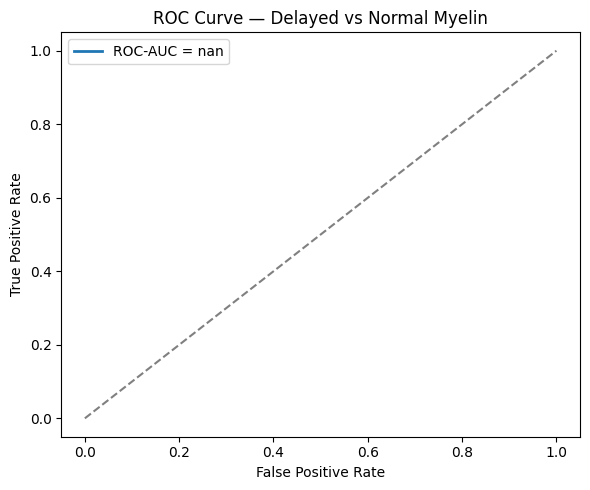

In [53]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC-AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Delayed vs Normal Myelin')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=120)
plt.show()

## 13. (Optional) GradCAM saliency on one test volume

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


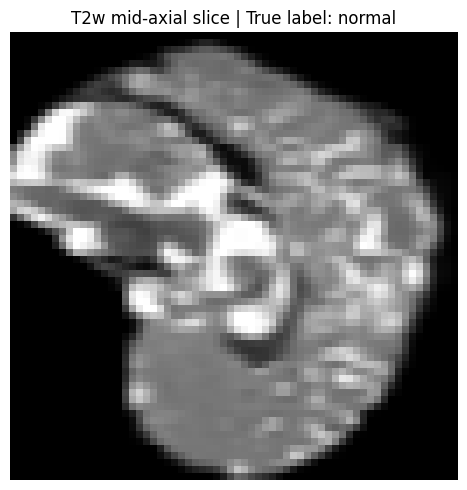

In [54]:
# Install grad-cam for 3D support
!pip install -q grad-cam

# Visualise a single mid-axial slice from the first test subject
sample_image, sample_label = test_ds[0]
sample_image = sample_image.unsqueeze(0).to(device)   # (1, 2, D, H, W)

# Show T2w mid-slice
t2_vol = sample_image[0, 1].cpu().numpy()             # (D, H, W)
mid    = t2_vol.shape[0] // 2

plt.figure(figsize=(5, 5))
plt.imshow(t2_vol[mid], cmap='gray')
plt.title(f"T2w mid-axial slice | True label: {'delayed' if sample_label==1 else 'normal'}")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/sample_t2w_slice.png', dpi=120)
plt.show()

---
## Notes
- **Dataset download** takes ~10–20 min; the ~833 NIfTI pairs are several GB total.
- **`TARGET_SHAPE`** is set to `(64,64,64)` to fit in GPU RAM. Raise to `(96,96,96)` for better accuracy at the cost of memory.
- **Class imbalance**: weighted cross-entropy is applied automatically based on label counts.
- **Accelerated class** is excluded by the binary filter in cell 4 — remove the filter and change `num_classes=3` to include it.
- **Cite the dataset**: Akinci D'Antonoli et al., Radiology: AI, https://pubs.rsna.org/doi/10.1148/ryai.220292